# XRD Phase Identification: Methods and Pitfalls

This notebook uses a synthetic diffraction pattern to illustrate a central methodological point from Leeman *et al.*: a visually plausible or numerically acceptable fit is not, by itself, proof of a new crystalline phase.

The analysis below compares an ordered-phase claim against known-phase alternatives and asks where the evidence is strong, where it is ambiguous, and where residual structure suggests missing chemistry.

# Paper Context

The motivating paper is Leeman *et al.*, PRX Energy 2024, which critiques phase-identification claims associated with the A-Lab workflow. The key issue is not whether an XRD pattern can be fitted, but whether the proposed phase assignment has been tested against chemically plausible alternatives.

The paper's critique can be summarized as four practical rules for diffraction-based phase identification.

### 1. Goodness-of-fit is not phase identity.
A global metric such as $\chi^2$ can improve even when chemically important peaks remain missing or misplaced. Residual structure should be inspected directly rather than reduced to a single score.

### 2. A discovery claim needs explicit alternatives.
If the claim is that a new material has been made, the proposed structure should be compared with known phases and plausible mixtures, not only fitted in isolation.

### 3. Small ordering peaks can carry large interpretive weight.
For cation ordering, a weak superlattice reflection can be decisive. Its absence or mismatch can undercut an ordered-phase assignment even if the global fit remains tolerable.

### 4. Impurity peaks require context.
A small impurity peak may be statistically visible but scientifically secondary, while an unfitted peak at a structurally important position may indicate that the model is incomplete.

These rules frame the synthetic case study below.

# Case Study Setup

## Synthetic XRD Case Study Inspired by Leeman *et al.*

The notebook constructs a powder-diffraction-like pattern from Gaussian peaks, background, and noise. The goal is to compare several candidate explanations for the same observed pattern:

- a flexible peak-only diagnostic fit
- a proposed ordered phase
- a known disordered phase
- a mixture of known phases

The comparison uses residual plots, $\chi^2$, reduced $\chi^2$, AIC, and an F-test. The main question is methodological: which conclusions are supported by the evidence, and which would be overinterpretation?

## Utility Functions

In [1]:
# ============================
# SETUP CELL (RUN FIRST)
# ============================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import f

# For nicer plots
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def multi_gaussian(x, amps, mus, sigmas):
    """
    Sum of multiple Gaussians.
    amps, mus, sigmas are 1D arrays of same length.
    """
    y = np.zeros_like(x)
    for A, m, s in zip(amps, mus, sigmas):
        y += gaussian(x, A, m, s)
    return y

def chi_square(y_obs, y_fit, sigma):
    """
    Compute chi-square given observed data, fit, and assumed constant sigma.
    """
    return np.sum(((y_obs - y_fit) / sigma)**2)

def aic_from_rss(rss, n_params, n_points):
    """
    AIC for least-squares fits with Gaussian errors.
    """
    return 2*n_params + n_points*np.log(rss/n_points)

def plot_fit(x, y_obs, y_fit, title="Fit", ylim=None):
    residuals = y_obs - y_fit
    fig, axes = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios':[3,1]})
    axes[0].plot(x, y_obs, '.', label='Data', markersize=3)
    axes[0].plot(x, y_fit, '-', label='Fit')
    axes[0].set_ylabel("Intensity (a.u.)")
    axes[0].set_title(title)
    axes[0].legend()

    axes[1].plot(x, residuals, '-', label='Residuals')
    axes[1].axhline(0, color='k', linewidth=1)
    axes[1].set_xlabel(r"2θ (deg)")
    axes[1].set_ylabel("Residual")
    if ylim is not None:
        axes[1].set_ylim(ylim)
    plt.tight_layout()
    plt.show()

def f_test(chi2_0, chi2_1, df0, df1):
    """
    F-test comparing model 0 (simpler) vs model 1 (more complex).
    chi2_0, chi2_1: chi-square values
    df0, df1: degrees of freedom (N - k0, N - k1)
    Returns F statistic and p-value.
    """
    num = (chi2_0 - chi2_1) / (df0 - df1)
    den = chi2_1 / df1
    F_stat = num / den
    p_value = 1 - f.cdf(F_stat, df0 - df1, df1)
    return F_stat, p_value

## Generate a Synthetic Diffraction Pattern

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure the necessary functions are defined (copied from setup cell for self-containment if needed)
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def multi_gaussian(x, amps, mus, sigmas):
    y = np.zeros_like(x)
    for A, m, s in zip(amps, mus, sigmas):
        y += gaussian(x, A, m, s)
    return y

np.random.seed(3) # Use a new seed for this problem for reproducibility

# 2. Define the x-axis range
x_new = np.linspace(10, 50, 2000)

# 3. Define the peak positions (mus)
mus_new = np.array([18.0, 30.0, 36.0, 37.0, 43.0])

# 4. Define the peak amplitudes (amps)
amps_new = np.array([1.3, 0.6, 2.0, 1.9, 3.9])

# 5. Set the peak width
sigma_new = 0.15

# 6. Generate the sum of Gaussian peaks
y_peaks_new = multi_gaussian(x_new, amps_new,
                             mus_new, np.full_like(mus_new, sigma_new))

# 7. Define a small linear background
background_new = 0.02 + 0.0005 * (x_new - x_new.mean())

# 8. Set the noise level
noise_sigma_new = 0.02

# 9. Generate Gaussian noise
noise_new = np.random.normal(0, noise_sigma_new, size=x_new.shape)

# 10. Combine the peaks, background, and noise
y_exp_new = y_peaks_new + background_new + noise_new

# Quick plot of the new

## Visualize the Synthetic Pattern

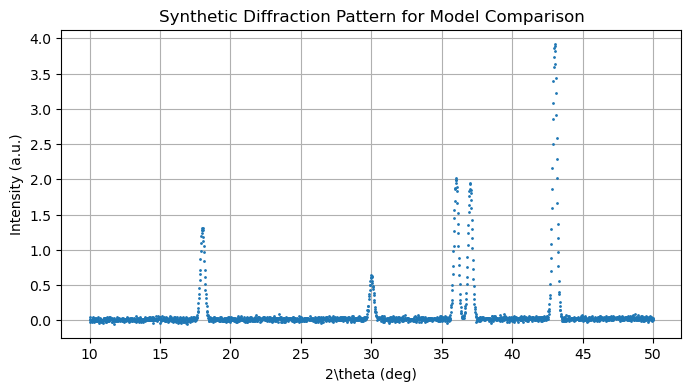

In [3]:
plt.plot(x_new, y_exp_new, '.', markersize=2)
plt.xlabel(r"2\theta (deg)")
plt.ylabel("Intensity (a.u.)")
plt.title("Synthetic Diffraction Pattern for Model Comparison")
plt.show()

## Reference Phase Models

In [4]:
import pandas as pd

# Reference peak positions and relative intensities for the candidate phase models.
df_xrd_fit_values = pd.DataFrame({
    "Peak": [1, 2, 3, 4, 5],
    "Angle": [18.0, 30.0, 36.0, 37.0, 43.0],
    "Int A": [2.0, 0.1, 1.0, 1.3, 3.5],
    "Int B": [1.0, 0.1, 1.8, 1.8, 2.2],
    "Int C": [0.0, 0.0, 0.0, 0.5, 0.5],
})

# Display the reference phase table.
display(df_xrd_fit_values)

,Peak,Angle,Int A,Int B,Int C
0,1,18.0,2.0,1.0,0.0
1,2,30.0,0.1,0.1,0.0
2,3,36.0,1.0,1.8,0.0
3,4,37.0,1.3,1.8,0.5
4,5,43.0,3.5,2.2,0.5


## Candidate Models

The synthetic pattern is fitted with four models:

- **Model 0**: five unconstrained Gaussians with a common peak width.
- **Model 1**: scaled ordered `Mg3MnNi3O8` pattern plus background.
- **Model 2**: scaled disordered `Ni-Mn-O` pattern plus background.
- **Model 3**: scaled disordered `Ni-Mn-O` plus `NiO` mixture and background.

### Initialize Analysis Variables

This cell defines the peak positions used for model comparison and stores phase-marker positions for the diagnostic plots.

In [5]:
# Constants from the problem setup
noise_sigma = noise_sigma_new
x_mean = x_new.mean()

# Define Phase Peaks for Plotting
angles_all = df_xrd_fit_values["Angle"].values
phase_peaks = {
    "Mg3MnNi3O8 (ord)": angles_all[df_xrd_fit_values["Int A"] > 0],
    "Ni-Mn-O (dis)": angles_all[df_xrd_fit_values["Int B"] > 0],
    "NiO": angles_all[df_xrd_fit_values["Int C"] > 0],
    "NiMn2O (?)": [30.0] # Peak 2
}

# Dictionary to store results
results = {}


### Model Definitions

The models share the same Gaussian peak shape but differ in how much physical structure is imposed. Model 0 is a flexible diagnostic baseline. Models 1-3 use reference peak positions and relative intensities to represent phase hypotheses.

In [6]:
# --- Model Definitions ---

# Model 0: 5 Unconstrained Gaussians + Common Sigma (No Background)
def model_0_func(x, sigma, a1, mu1, a2, mu2, a3, mu3, a4, mu4, a5, mu5):
    amps = [a1, a2, a3, a4, a5]
    mus = [mu1, mu2, mu3, mu4, mu5]
    y = np.zeros_like(x)
    for A, m in zip(amps, mus):
        y += gaussian(x, A, m, sigma)
    return y

# Model 1 & 2 Wrapper: Scaled Phase + Background + Common Sigma
def create_scaled_model_func(angles, relative_intensities):
    def model_func(x, scale, bg_intercept, bg_slope, sigma):
        y_signal = np.zeros_like(x)
        for mu, rel_int in zip(angles, relative_intensities):
            y_signal += gaussian(x, scale * rel_int, mu, sigma)
        y_bg = bg_intercept + bg_slope * (x - x_mean)
        return y_signal + y_bg
    return model_func

# Model 3: Mixture (B + C) + Background + Common Sigma
def model_3_func(x, scale_B, scale_C, bg_intercept, bg_slope, sigma):
    y_signal = np.zeros_like(x)
    # Int B
    for mu, rel_int in zip(angles_all, df_xrd_fit_values["Int B"].values):
        y_signal += gaussian(x, scale_B * rel_int, mu, sigma)
    # Int C
    for mu, rel_int in zip(angles_all, df_xrd_fit_values["Int C"].values):
        y_signal += gaussian(x, scale_C * rel_int, mu, sigma)
    y_bg = bg_intercept + bg_slope * (x - x_mean)
    return y_signal + y_bg



### Fit the Models

This cell fits the flexible Gaussian baseline and the three constrained phase models using non-linear least squares. The constrained models fit scale factors, background terms, and a common peak width.

In [7]:
# --- Fitting ---

# Initial guesses
p0_sigma = 0.15
p0_bg = [0.02, 0.0] # intercept, slope

# Model 0 Fit
# Guess: sigma, then 5 pairs of (A, mu)
p0_m0 = [p0_sigma]
for i in range(5):
    p0_m0.extend([amps_new[i], mus_new[i]])

popt_0, _ = curve_fit(model_0_func, x_new, y_exp_new, p0=p0_m0, sigma=np.full_like(x_new, noise_sigma))
y_fit_0 = model_0_func(x_new, *popt_0)

# Model 1 Fit (Phase A)
model_1_func = create_scaled_model_func(angles_all, df_xrd_fit_values["Int A"].values)
p0_m1 = [1.0, *p0_bg, p0_sigma] # scale, bg_int, bg_slope, sigma
popt_1, _ = curve_fit(model_1_func, x_new, y_exp_new, p0=p0_m1, sigma=np.full_like(x_new, noise_sigma))
y_fit_1 = model_1_func(x_new, *popt_1)

# Model 2 Fit (Phase B)
model_2_func = create_scaled_model_func(angles_all, df_xrd_fit_values["Int B"].values)
p0_m2 = [1.0, *p0_bg, p0_sigma]
popt_2, _ = curve_fit(model_2_func, x_new, y_exp_new, p0=p0_m2, sigma=np.full_like(x_new, noise_sigma))
y_fit_2 = model_2_func(x_new, *popt_2)

# Model 3 Fit (Phase B + C)
p0_m3 = [1.0, 0.5, *p0_bg, p0_sigma] # scale_B, scale_C, bg_int, bg_slope, sigma
popt_3, _ = curve_fit(model_3_func, x_new, y_exp_new, p0=p0_m3, sigma=np.full_like(x_new, noise_sigma))
y_fit_3 = model_3_func(x_new, *popt_3)


### Model Comparison Tables

This cell summarizes fitted peak amplitudes and fit statistics. The statistics are useful for ranking models, but they should be interpreted together with residual plots and phase-specific peak evidence.

In [8]:
# --- Collect Results & Statistics ---

models_data = [
    {"name": "Model 0", "y_fit": y_fit_0, "popt": popt_0, "dof_k": len(popt_0)},
    {"name": "Model 1", "y_fit": y_fit_1, "popt": popt_1, "dof_k": len(popt_1)},
    {"name": "Model 2", "y_fit": y_fit_2, "popt": popt_2, "dof_k": len(popt_2)},
    {"name": "Model 3", "y_fit": y_fit_3, "popt": popt_3, "dof_k": len(popt_3)}
]

stats_list = []
params_summary = {
    "Peak 1 (18 deg) Amp": [],
    "Peak 2 (30 deg) Amp": [],
    "Peak 3 (36 deg) Amp": [],
    "Peak 4 (37 deg) Amp": [],
    "Peak 5 (43 deg) Amp": [],
    "Common Sigma": [],
    "Background b0": [],
    "Background b1": [],
    "Scale Factor B": [],
    "Scale Factor C": []
}

for m in models_data:
    # Stats
    rss = np.sum((y_exp_new - m["y_fit"])**2)
    chi2 = chi_square(y_exp_new, m["y_fit"], noise_sigma)
    n_points = len(x_new)
    k = m["dof_k"]
    red_chi2 = chi2 / (n_points - k)
    aic = aic_from_rss(rss, k, n_points)

    stats_list.append({
        "Model": m["name"],
        "RSS": rss,
        "Chi2": chi2,
        "Reduced Chi2": red_chi2,
        "AIC": aic
    })

    # Parameters
    p = m["popt"]
    name = m["name"]

    # Initialize values
    amps = np.zeros(5)
    sigma = 0
    bg0 = np.nan
    bg1 = np.nan
    scale_b = np.nan
    scale_c = np.nan

    if name == "Model 0":
        # p = [sigma, a1, mu1, a2, mu2, ...]
        sigma = p[0]
        for i in range(5):
            amps[i] = p[1 + 2*i]
        # No bg, no scales

    elif name == "Model 1":
        # p = [scale, bg0, bg1, sigma]
        scale = p[0]
        bg0 = p[1]
        bg1 = p[2]
        sigma = p[3]
        amps = scale * df_xrd_fit_values["Int A"].values

    elif name == "Model 2":
        # p = [scale, bg0, bg1, sigma]
        scale = p[0]
        bg0 = p[1]
        bg1 = p[2]
        sigma = p[3]
        scale_b = scale
        amps = scale * df_xrd_fit_values["Int B"].values

    elif name == "Model 3":
        # p = [scale_B, scale_C, bg0, bg1, sigma]
        scale_b = p[0]
        scale_c = p[1]
        bg0 = p[2]
        bg1 = p[3]
        sigma = p[4]
        amps = scale_b * df_xrd_fit_values["Int B"].values + scale_c * df_xrd_fit_values["Int C"].values

    # Fill summary dict
    params_summary["Peak 1 (18 deg) Amp"].append(amps[0])
    params_summary["Peak 2 (30 deg) Amp"].append(amps[1])
    params_summary["Peak 3 (36 deg) Amp"].append(amps[2])
    params_summary["Peak 4 (37 deg) Amp"].append(amps[3])
    params_summary["Peak 5 (43 deg) Amp"].append(amps[4])
    params_summary["Common Sigma"].append(sigma)
    params_summary["Background b0"].append(bg0)
    params_summary["Background b1"].append(bg1)
    params_summary["Scale Factor B"].append(scale_b)
    params_summary["Scale Factor C"].append(scale_c)

# --- Display Tables ---
import pandas as pd

print("\nSummary of Fitted Parameters")
df_params = pd.DataFrame(params_summary, index=["Model 0", "Model 1", "Model 2", "Model 3"]).T
display(df_params)

print("\nComparison of Fit Statistics")
df_stats = pd.DataFrame(stats_list)
display(df_stats)

# This section processes the fitted parameters from various models,
# aggregates them into a summary dictionary, and then converts these summaries
# into pandas DataFrames for display. It prints two tables: a summary of
# the fitted parameters for each model and a comparison of fit statistics,
# both formatted using markdown.




Summary of Fitted Parameters


,Model 0,Model 1,Model 2,Model 3
Peak 1 (18 deg) Amp,1.315925,2.184283,1.374812,1.235806
Peak 2 (30 deg) Amp,0.621921,0.109214,0.137481,0.123581
Peak 3 (36 deg) Amp,2.016066,1.092142,2.474661,2.224451
Peak 4 (37 deg) Amp,1.927297,1.419784,2.474661,2.652939
Peak 5 (43 deg) Amp,3.911134,3.822496,3.024586,3.147261
Common Sigma,0.151926,0.148641,0.149647,0.149700
Background b0,NaN,0.030212,0.021624,0.022551
Background b1,NaN,0.001900,0.000826,0.000613
Scale Factor B,NaN,NaN,1.374812,1.235806
Scale Factor C,NaN,NaN,NaN,0.856976



Comparison of Fit Statistics


,Model,RSS,Chi2,Reduced Chi2,AIC
0,Model 0,1.525920,3814.801052,1.917949,-14334.609354
1,Model 1,27.651414,69128.535936,34.633535,-8554.451160
2,Model 2,21.143899,52859.748042,26.482840,-9091.102098
3,Model 3,19.447770,48619.424944,24.370639,-9256.340100


## Visual Diagnostics

The plots compare the observed pattern with the fitted models and show residuals. For the mixture model, phase tick marks indicate where the known `Ni-Mn-O` and `NiO` peaks are expected.

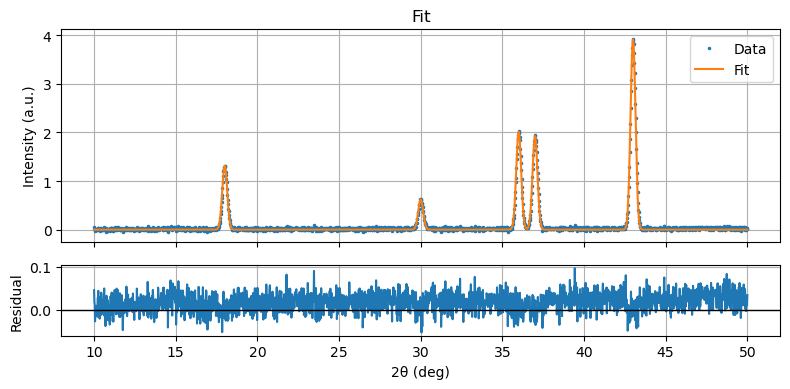

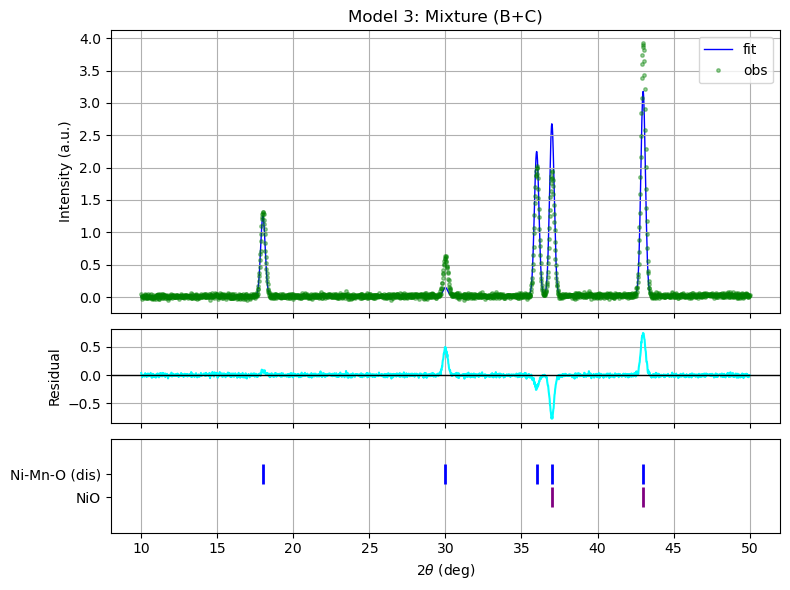

In [9]:
# --- Plots ---
# Updated plot_fit to show peak indices stacked BELOW residuals
def plot_fit_with_indices(x, y_obs, y_fit, title="Fit", ylim=None, peak_dict=None):
    residuals = y_obs - y_fit

    # Create 3 subplots: Main, Residuals, Indices
    # Height ratios: Main (3), Residuals (1), Indices (1)
    fig, axes = plt.subplots(3, 1, sharex=True, gridspec_kw={'height_ratios':[3, 1, 1]}, figsize=(8, 6))

    # --- 1. Main Plot ---
    # Fit first (zorder 1), Obs second (zorder 2)
    axes[0].plot(x, y_fit, '-', label='fit', color='blue', linewidth=1, zorder=1)
    axes[0].plot(x, y_obs, '.', label='obs', markersize=5, color='green', zorder=2, alpha=0.4)
    axes[0].set_ylabel("Intensity (a.u.)")
    axes[0].set_title(title)
    axes[0].legend(loc='upper right')
    axes[0].grid(True)

    # --- 2. Residual Plot ---
    axes[1].plot(x, residuals, '-', label='Residuals', color='cyan')
    axes[1].axhline(0, color='k', linewidth=1)
    axes[1].set_ylabel("Residual")
    if ylim is not None:
        axes[1].set_ylim(ylim)
    axes[1].grid(True)

    # --- 3. Index Plot ---
    if peak_dict:
        # Define order: A, B, C, D
        # Map keys to this order
        ordered_keys = [
            "Mg3MnNi3O8 (ord)", # A
            "Ni-Mn-O (dis)",    # B
            "NiO",              # C
            "NiMn2O (?)"        # D
        ]

        colors = ['red', 'blue', 'purple', 'orange']

        # We will plot them at y = 0, -1, -2, -3
        # And set y-ticks to the labels
        yticks = []
        yticklabels = []

        for i, key in enumerate(ordered_keys):
            if key in peak_dict:
                angles = peak_dict[key]
                y_level = -i
                c = colors[i % len(colors)]

                # Plot ticks
                axes[2].plot(angles, np.full_like(angles, y_level), '|', color=c, markersize=15, markeredgewidth=2)

                yticks.append(y_level)
                yticklabels.append(key)

        # Configure Index Axes
        axes[2].set_yticks(yticks)
        axes[2].set_yticklabels(yticklabels)
        axes[2].set_ylim(-len(ordered_keys) + 0.5, 0.5)
        axes[2].grid(False) # Grid might be distracting here, or we can keep x-grid
        axes[2].grid(True, axis='x')

    axes[2].set_xlabel(r"2$\theta$ (deg)")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1) # Reduce gap between subplots
    plt.show()

# Plot Model 0
plot_fit(x_new, y_exp_new, y_fit_0, title="Fit", ylim=None)
# plot_fit_with_indices(x_new, y_exp_new, y_fit_0, title="Model 0: 5 Unconstrained Gaussians", peak_dict=None)


# Plot Model 3
plot_peaks_3 = {
    "Ni-Mn-O (dis)": phase_peaks["Ni-Mn-O (dis)"],
    "NiO": phase_peaks["NiO"]
}
plot_fit_with_indices(x_new, y_exp_new, y_fit_3, title="Model 3: Mixture (B+C)", peak_dict=plot_peaks_3)



## F-test: Does Adding `NiO` Matter?

The F-test compares Model 2, the simpler disordered-phase model, with Model 3, the disordered-plus-`NiO` mixture. It asks whether the extra mixture parameter gives a statistically meaningful improvement.

In [10]:
# --- F-Test ---
import numpy as np
from scipy.stats import f

# N is the number of data points (N=2000 from x_new in the setup)
N = n_points

# Model 2 (Simpler: Phase B + Background)
chi2_0 = stats_list[2]['Chi2']
k0 = 4  # Parameters: Scale B, bg_intercept, bg_slope, sigma
df0 = N - k0

# Model 3 (Complex: Phase B + C + Background)
chi2_1 = stats_list[3]['Chi2']
k1 = 5  # Parameters: Scale B, Scale C, bg_intercept, bg_slope, sigma
df1 = N - k1

# Perform F-test
F_stat, p_value = f_test(chi2_0, chi2_1, df0, df1)

print(f"\n--- F-Test: Model 2 (B) vs Model 3 (B+C) ---")
print(f"Model 2 Chi^2 / k / df: {chi2_0:.1f} / {k0} / {df0}")
print(f"Model 3 Chi^2 / k / df: {chi2_1:.1f} / {k1} / {df1}")
print(f"F Statistic: {F_stat:.2f}")
print(f"P-value: {p_value:.10f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print(f"Conclusion (at alpha={alpha}): Reject H0. Model 3 provides a statistically SIGNIFICANT improvement over Model 2.")
else:
    print(f"Conclusion (at alpha={alpha}): Do not reject H0. Model 3 does not provide a statistically significant improvement.")



--- F-Test: Model 2 (B) vs Model 3 (B+C) ---
Model 2 Chi^2 / k / df: 52859.7 / 4 / 1996
Model 3 Chi^2 / k / df: 48619.4 / 5 / 1995
F Statistic: 173.99
P-value: 0.0000000000
Conclusion (at alpha=0.05): Reject H0. Model 3 provides a statistically SIGNIFICANT improvement over Model 2.


# Interpretation

## Which model is most defensible?

Model 0 has the best numerical fit because it allows peak positions and amplitudes to float freely. That makes it a useful diagnostic baseline, but not a phase identification.

Among the phase-constrained hypotheses, Model 3 is the strongest explanation. It has RSS = 19.4478, reduced $\chi^2$ = 24.3706, and AIC = -9256.34, outperforming both the ordered `Mg3MnNi3O8` claim and the single disordered `Ni-Mn-O` model. The F-test also shows that adding `NiO` significantly improves the model relative to Model 2.

## What does this say about XRD phase identification?

Model 3 is the best of the constrained models, but the conclusion is not simply "Model 3 wins." The exercise shows why phase identification requires scientific judgment beyond a goodness-of-fit table.

- **Test plausible alternatives.** The ordered `Mg3MnNi3O8` model should not be accepted just because it can be fitted. A mixture of known `Ni-Mn-O` and `NiO` explains the data better.

- **Inspect chemically meaningful peaks.** The ordered model overestimates the ordering-related peak near 18 degrees. For a cation-ordering claim, that local mismatch matters.

- **Read residuals as evidence.** Model 2 leaves residual structure because it misses `NiO`; Model 3 reduces that residual by adding the impurity phase.

- **Do not stop at the best available model.** Model 3 still misses intensity near 30 degrees, suggesting that another phase, such as `NiMn2O4`, could be present. The best model in a limited candidate set can still be incomplete.

The broader lesson is that XRD phase identification is a model-comparison problem, not a single-model confirmation problem.